INITIAL SANITY CHECK

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Importing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
raw_data = pd.read_csv('/content/drive/MyDrive/Global OpenAQ raw data.csv')
raw_data.head()

,location,city,country,pollutant,value,timestamp,unit,source_name,latitude,longitude,averaged_over_in_hours,location_geom
0,"Czerwionka-Leszczyny, ul. Kopalniana",Czerwionka-Leszczyny,PL,bc,1.11387,2022-05-11 02:00:00 UTC,µg/m³,GIOS,1.0,50.163850,18.659977,POINT(50.16385 1)
1,"Rybnik, ul. Borki",Rybnik,PL,bc,0.87575,2022-05-15 06:00:00 UTC,µg/m³,GIOS,1.0,50.111181,18.516139,POINT(50.111181 1)
2,"Zielonka, Bory Tucholskie",Zielonka,PL,bc,0.04000,2022-05-09 09:00:00 UTC,µg/m³,GIOS,1.0,53.662136,17.933986,POINT(53.662136 1)
3,Zielona Góra ul. Krótka,Zielona Góra,PL,bc,0.19274,2022-05-17 06:00:00 UTC,µg/m³,GIOS,1.0,51.939783,15.518861,POINT(51.939783 1)
4,"Płock, ul. Reja",Płock,PL,bc,0.65000,2022-05-07 18:00:00 UTC,µg/m³,GIOS,1.0,52.550938,19.709791,POINT(52.550938 1)


In [ ]:
raw_data.shape

(5594614, 12)

In [ ]:
raw_data = raw_data.sort_values(by='timestamp')
raw_data.head(10)

,location,city,country,pollutant,value,timestamp,unit,source_name,latitude,longitude,averaged_over_in_hours,location_geom
5286795,JTC - Jamestown,Accra,GH,pm25,51.77,2007-02-09 07:00:00 UTC,µg/m³,Dr. Raphael E. Arku and Colleagues,44.000000,5.534919,-0.212406,POINT(5.5349194 44)
2526321,JTC - Jamestown,Accra,GH,pm25,51.77,2007-02-09 07:00:00 UTC,µg/m³,Dr. Raphael E. Arku and Colleagues,5.534919,-0.212406,48.000000,POINT(-0.2124056 5.5349193)
612325,JTC - Jamestown,Accra,GH,pm10,99.32,2007-02-09 07:00:00 UTC,µg/m³,Dr. Raphael E. Arku and Colleagues,44.000000,5.534919,-0.212406,POINT(5.5349194 44)
3045859,JTC - Jamestown,Accra,GH,pm10,99.32,2007-02-09 07:00:00 UTC,µg/m³,Dr. Raphael E. Arku and Colleagues,5.534919,-0.212406,48.000000,POINT(-0.2124056 5.5349193)
2483331,ADT - Asylum Down,Accra,GH,pm10,74.27,2007-04-08 06:20:00 UTC,µg/m³,Dr. Raphael E. Arku and Colleagues,45.000000,5.570722,-0.212056,POINT(5.570722 45)
5130692,ADT - Asylum Down,Accra,GH,pm25,33.07,2007-04-08 06:20:00 UTC,µg/m³,Dr. Raphael E. Arku and Colleagues,45.000000,5.570722,-0.212056,POINT(5.570722 45)
4921681,ADT - Asylum Down,Accra,GH,pm25,33.07,2007-04-08 06:20:00 UTC,µg/m³,Dr. Raphael E. Arku and Colleagues,5.570722,-0.212056,48.000000,POINT(-0.2120555 5.570722)
4931288,ADT - Asylum Down,Accra,GH,pm10,74.27,2007-04-08 06:20:00 UTC,µg/m³,Dr. Raphael E. Arku and Colleagues,5.570722,-0.212056,48.000000,POINT(-0.2120555 5.570722)
4566392,ADEPA - Asylum Down,Accra,GH,pm10,40.32,2007-04-08 06:54:00 UTC,µg/m³,Dr. Raphael E. Arku and Colleagues,46.000000,5.567833,-0.204028,POINT(5.567833 46)
5313220,ADEPA - Asylum Down,Accra,GH,pm25,21.65,2007-04-08 06:54:00 UTC,µg/m³,Dr. Raphael E. Arku and Colleagues,5.567833,-0.204028,49.000000,POINT(-0.2040278 5.567833)


In [ ]:
raw_data.duplicated().sum()

np.int64(0)

FILTERING DATA FROM 2016-2022

In [ ]:
# Filtering data from 2016-2022
raw_data['timestamp'] = pd.to_datetime(raw_data['timestamp'])
raw_data_2016_2022 = raw_data.loc[raw_data['timestamp'] >= '2016-01-01 00:00:00 UTC']
raw_data_2016_2022.head(10)

,location,city,country,pollutant,value,timestamp,unit,source_name,latitude,longitude,averaged_over_in_hours,location_geom
1216140,Income Tax Office,Delhi,IN,o3,28.0000,2016-01-23 03:15:00+00:00,µg/m³,CPCB,28.6235,77.249400,0.250000,POINT(77.2494 28.6235)
1723196,Income Tax Office,Delhi,IN,co,90.0000,2016-01-23 03:15:00+00:00,µg/m³,CPCB,28.6235,77.249400,0.250000,POINT(77.2494 28.6235)
4745709,Haringey - Haringey Town Hall,Haringey,GB,pm25,10.0000,2016-02-09 20:00:00+00:00,µg/m³,London Air Quality Network,1.0000,51.599302,-0.068218,POINT(51.599302 1)
4197718,Haringey - Haringey Town Hall,Haringey,GB,pm25,10.0000,2016-02-09 20:00:00+00:00,µg/m³,DEFRA,1.0000,51.599302,-0.068218,POINT(51.599302 1)
4562746,Haringey Roadside,London,GB,pm25,10.0000,2016-02-09 20:00:00+00:00,µg/m³,DEFRA,1.0000,51.599300,-0.068218,POINT(51.5993 1)
4230380,Los Vientos,Llayllay,CL,pm10,57.8700,2016-02-16 18:00:00+00:00,µg/m³,Chile - SINCA,1.0000,-32.833639,-70.996930,POINT(-32.833639 1)
2116204,Los Vientos,Llayllay,CL,co,740.7000,2016-02-16 18:00:00+00:00,µg/m³,Chile - SINCA,1.0000,-32.833639,-70.996930,POINT(-32.833639 1)
2079388,Los Vientos,Llayllay,CL,so2,0.1651,2016-02-16 18:00:00+00:00,µg/m³,Chile - SINCA,1.0000,-32.833639,-70.996930,POINT(-32.833639 1)
418941,Los Vientos,Llayllay,CL,o3,983.1000,2016-02-16 18:00:00+00:00,µg/m³,Chile - SINCA,1.0000,-32.833639,-70.996930,POINT(-32.833639 1)
1345090,"Na An, Mueang",Loei,TH,co,0.7000,2016-02-19 01:00:00+00:00,ppm,Thailand,1.0000,13.763936,100.529078,POINT(13.763936293311 1)


In [ ]:
raw_data_2016_2022.shape

(5594511, 12)

DISTRIBUTION OF POLLUTANTS

/tmp/ipython-input-131980689.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


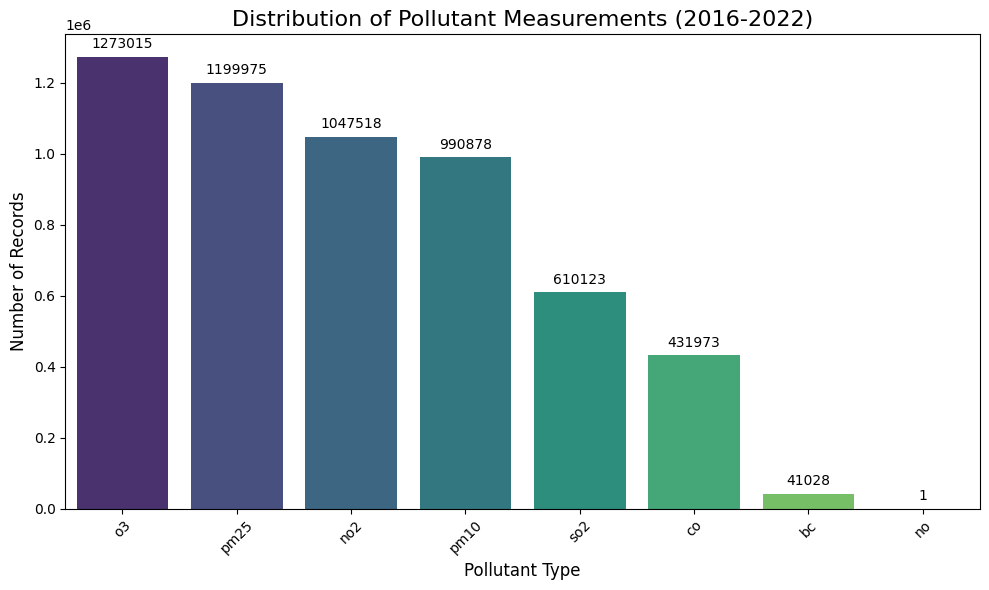

In [ ]:
# Understanding the disrtibution of pollutants
plt.figure(figsize=(10, 6))

# Create the Countplot
ax = sns.countplot(
    data=raw_data_2016_2022,
    x='pollutant',
    order=raw_data_2016_2022['pollutant'].value_counts().index,
    palette='viridis'
)

# Add title and labels
plt.title('Distribution of Pollutant Measurements (2016-2022)', fontsize=16)
plt.xlabel('Pollutant Type', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)
plt.xticks(rotation=45)

# Add the exact count numbers on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

In [ ]:
# Checkpoint
raw_wide = raw_data_2016_2022.copy()

CONVERTING DATA FROM LONG INTO WIDE FORMAT

In [ ]:
# Unpivotting the data
daily = (
    raw_wide
    .groupby([
        'location',
        'city',
        'country',
        'timestamp',
        'pollutant'
    ], as_index=False)
    .agg({
        'value': 'mean',
        'latitude': 'first',
        'longitude': 'first',
        'source_name': 'first',
        'location_geom': 'first'
    })
)

raw_wide = (
    daily
    .pivot_table(
        index=[
            'location',
            'city',
            'country',
            'timestamp',
            'latitude',
            'longitude',
            'source_name',
            'location_geom'
        ],
        columns='pollutant',
        values='value',
        aggfunc='mean'   # safety net
    )
    .reset_index()
)




In [ ]:
# Dropping non-significant columns
raw_wide = raw_wide.drop(['no','bc'], axis = 1)
raw_wide.columns

Index(['location', 'city', 'country', 'timestamp', 'latitude', 'longitude',
       'source_name', 'location_geom', 'co', 'no2', 'o3', 'pm10', 'pm25',
       'so2'],
      dtype='object', name='pollutant')

In [ ]:
# Renaming the columns
import pandas as pd

# Reset Index to make 'pollutant' a normal part of the header, not a label
raw_wide = raw_wide.reset_index()


# Rename the Columns (The Clean-Up)
rename_map = {
    'pm25': 'PM2.5 (µg/m³)',
    'pm10': 'PM10 (µg/m³)',
    'no2': 'NO2 (µg/m³)',
    'o3': 'O3 (µg/m³)',
    'so2': 'SO2 (µg/m³)',
    'co': 'CO (ppm)'
}

# Apply the renaming
raw_wide.rename(columns=rename_map, inplace=True)

# Clean up the "Index Name"
raw_wide.columns.name = None

# Check the final look
print(raw_wide.columns.tolist())


['index', 'location', 'city', 'country', 'timestamp', 'latitude', 'longitude', 'source_name', 'location_geom', 'CO (ppm)', 'NO2 (µg/m³)', 'O3 (µg/m³)', 'PM10 (µg/m³)', 'PM2.5 (µg/m³)', 'SO2 (µg/m³)']


In [ ]:
# Sorting the data by date
raw_wide = raw_wide.sort_values(by='timestamp')
raw_wide.drop(columns='index',inplace=True)
raw_wide.head(10)

,location,city,country,timestamp,latitude,longitude,source_name,location_geom,CO (ppm),NO2 (µg/m³),O3 (µg/m³),PM10 (µg/m³),PM2.5 (µg/m³),SO2 (µg/m³)
1170604,Income Tax Office,Delhi,IN,2016-01-23 03:15:00+00:00,28.623500,77.249400,CPCB,POINT(77.2494 28.6235),90.0,NaN,28.00,NaN,NaN,NaN
962508,Haringey - Haringey Town Hall,Haringey,GB,2016-02-09 20:00:00+00:00,1.000000,51.599302,London Air Quality Network,POINT(51.599302 1),NaN,NaN,NaN,NaN,10.000,NaN
962971,Haringey Roadside,London,GB,2016-02-09 20:00:00+00:00,1.000000,51.599300,DEFRA,POINT(51.5993 1),NaN,NaN,NaN,NaN,10.000,NaN
1384037,Los Vientos,Llayllay,CL,2016-02-16 18:00:00+00:00,1.000000,-32.833639,Chile - SINCA,POINT(-32.833639 1),740.7,NaN,983.10,57.87,NaN,0.1651
1545663,"Na An, Mueang",Loei,TH,2016-02-19 01:00:00+00:00,1.000000,13.763936,Thailand,POINT(13.763936293311 1),0.7,NaN,NaN,NaN,NaN,NaN
83057,Alto Hospicio,Alto Hospicio,CL,2016-02-23 11:00:00+00:00,1.000000,-20.259620,Chile - SINCA,POINT(-20.259620485825 1),NaN,NaN,NaN,NaN,4.270,NaN
83058,Alto Hospicio,Alto Hospicio,CL,2016-02-23 12:00:00+00:00,1.000000,-20.290859,Chile - SINCA,POINT(-20.290859340668 1),NaN,NaN,NaN,NaN,5.630,NaN
657351,Escuela E-10,Tocopilla,CL,2016-02-24 21:00:00+00:00,1.000000,-22.087000,Chile - SINCA,POINT(-22.087 1),614.2,10.66,19.31,51.55,6.194,0.0000
546120,Derry,Derry,GB,2016-03-02 17:00:00+00:00,0.250000,55.001225,DEFRA,POINT(55.001225 0.25),NaN,NaN,NaN,NaN,NaN,10.0000
546121,Derry,Derry,GB,2016-03-02 17:00:00+00:00,55.001225,-7.329115,DEFRA,POINT(-7.329115 55.001225),NaN,7.00,NaN,NaN,NaN,NaN


In [ ]:
raw_wide.shape

(2431075, 14)

In [ ]:
raw_wide.duplicated().sum()

np.int64(0)

In [ ]:
# Understanding the proportions of not NaN rows
coverage = 1 - (raw_wide.isna().sum() / len(raw_wide))
coverage.sort_values(ascending=False)


,0
location,1.000000
city,1.000000
country,1.000000
timestamp,1.000000
latitude,1.000000
longitude,1.000000
source_name,1.000000
location_geom,1.000000
O3 (µg/m³),0.514695
PM2.5 (µg/m³),0.481457


FILTERING DATA

In [ ]:
# Introducing pollutant_count column
pollutants = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'O3 (µg/m³)', 'SO2 (µg/m³)','CO (ppm)']
raw_wide['pollutant_count'] = raw_wide[pollutants].notna().sum(axis=1)
raw_wide['pollutant_count'].value_counts().sort_index()


,count
pollutant_count,
0,1673
1,1002217
2,681064
3,297879
4,172425
5,132596
6,143221


In [ ]:
# Removing the rows which have all NaN values across pollutants
raw_wide = raw_wide[raw_wide['pollutant_count'] > 0]
raw_wide.head()

,location,city,country,timestamp,latitude,longitude,source_name,location_geom,CO (ppm),NO2 (µg/m³),O3 (µg/m³),PM10 (µg/m³),PM2.5 (µg/m³),SO2 (µg/m³),pollutant_count
1170604,Income Tax Office,Delhi,IN,2016-01-23 03:15:00+00:00,28.6235,77.249400,CPCB,POINT(77.2494 28.6235),90.0,NaN,28.0,NaN,NaN,NaN,2
962508,Haringey - Haringey Town Hall,Haringey,GB,2016-02-09 20:00:00+00:00,1.0000,51.599302,London Air Quality Network,POINT(51.599302 1),NaN,NaN,NaN,NaN,10.0,NaN,1
962971,Haringey Roadside,London,GB,2016-02-09 20:00:00+00:00,1.0000,51.599300,DEFRA,POINT(51.5993 1),NaN,NaN,NaN,NaN,10.0,NaN,1
1384037,Los Vientos,Llayllay,CL,2016-02-16 18:00:00+00:00,1.0000,-32.833639,Chile - SINCA,POINT(-32.833639 1),740.7,NaN,983.1,57.87,NaN,0.1651,4
1545663,"Na An, Mueang",Loei,TH,2016-02-19 01:00:00+00:00,1.0000,13.763936,Thailand,POINT(13.763936293311 1),0.7,NaN,NaN,NaN,NaN,NaN,1


In [ ]:
# Converting to datetime object
raw_wide['timestamp'] = pd.to_datetime(raw_wide['timestamp'], errors='coerce')

In [ ]:
# Sanity check for data types
raw_wide.dtypes

,0
location,object
city,object
country,object
timestamp,"datetime64[ns, UTC]"
latitude,float64
longitude,float64
source_name,object
location_geom,object
CO (ppm),float64
NO2 (µg/m³),float64


In [ ]:
raw_wide.isna().sum()

,0
location,0
city,0
country,0
timestamp,0
latitude,0
longitude,0
source_name,0
location_geom,0
CO (ppm),2003298
NO2 (µg/m³),1396615


HANDLING OUTLIERS

In [ ]:
raw_wide.describe()

,latitude,longitude,CO (ppm),NO2 (µg/m³),O3 (µg/m³),PM10 (µg/m³),PM2.5 (µg/m³),SO2 (µg/m³),pollutant_count
count,2.429402e+06,2.429402e+06,4.261040e+05,1.032787e+06,1.251263e+06,9.860610e+05,1.170458e+06,6.033150e+05,2.429402e+06
mean,2.868207e+00,3.445585e+01,3.632593e+02,-7.440516e+00,2.180560e+01,4.757697e+01,2.998884e-02,4.055740e+01,2.251578e+00
std,6.343145e+00,2.368915e+01,3.710895e+03,1.489526e+02,1.242739e+02,2.683696e+04,1.767578e+02,1.994714e+04,1.479941e+00
min,-4.316890e+01,-1.617670e+02,-8.812000e+05,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,1.000000e+00
25%,1.000000e+00,3.129129e+01,3.000000e-01,8.000000e-01,3.200000e-02,1.170700e+01,3.900000e+00,1.000000e-03,1.000000e+00
50%,1.000000e+00,4.166639e+01,2.000000e+02,8.117340e+00,5.400000e-02,2.000000e+01,7.600000e+00,2.000000e+00,2.000000e+00
75%,1.000000e+00,4.872444e+01,5.000000e+02,1.820000e+01,5.709865e+01,3.800000e+01,1.600000e+01,7.000000e+00,3.000000e+00
max,7.890669e+01,1.534020e+02,1.428573e+06,1.264425e+04,6.918000e+03,2.664761e+07,1.000000e+04,1.394914e+07,6.000000e+00


In [ ]:
#Checkpoint
raw_wide_clean_outliers = raw_wide.copy()

In [ ]:
# OUTLIER AUDIT

# Define the limits
constraints = {
    'PM2.5 (µg/m³)': (0, 1000),
    'PM10 (µg/m³)':  (0, 1000),
    'NO2 (µg/m³)':   (0, 1000),
    'SO2 (µg/m³)':   (0, 1000),
    'O3 (µg/m³)':    (0, 600),
    'CO (µg/m³)':    (0, 50000)
}

print(f"{'POLLUTANT':<20} | {'LIMITS':<15} | {'OUTLIERS FOUND':<15} | {'% OF DATA'}")
print("-" * 70)

total_rows = len(raw_wide)

for col, (min_val, max_val) in constraints.items():
    if col in raw_wide.columns:
        # Find the rows that are OUTSIDE the limits
        outlier_mask = (raw_wide[col] < min_val) | (raw_wide[col] > max_val)

        # Count them
        count = outlier_mask.sum()
        percent = (count / total_rows) * 100

        # Print the report
        print(f"{col:<20} | {min_val}-{max_val:<9} | {count:<15} | {percent:.4f}%")

POLLUTANT            | LIMITS          | OUTLIERS FOUND  | % OF DATA
----------------------------------------------------------------------
PM2.5 (µg/m³)        | 0-1000      | 32607           | 1.3422%
PM10 (µg/m³)         | 0-1000      | 17219           | 0.7088%
NO2 (µg/m³)          | 0-1000      | 23728           | 0.9767%
SO2 (µg/m³)          | 0-1000      | 11055           | 0.4551%
O3 (µg/m³)           | 0-600       | 8045            | 0.3312%


In [ ]:
import numpy as np
import pandas as pd

def fix_co_units(val):
    if pd.isna(val):
        return val
    # If val < 50, it's likely ppm -> convert to µg/m³ (x 1145)
    # If val > 50, it's likely µg/m³
    if val < 50:
        return val * 1145
    else:
        return val

def standardize_pollutants(df):
    df_fixed = df.copy()

    if 'CO (ppm)' in df_fixed.columns:
        print("Applying CO unit fix...")
        df_fixed['CO (µg/m³)'] = df_fixed['CO (ppm)'].apply(fix_co_units)
        df_fixed = df_fixed.drop(columns=['CO (ppm)'])

    factors = {
        'NO2': 1880,
        'SO2': 2620,
        'O3':  1960
    }

    # Strict Thresholds
    thresholds = {
        'NO2': 1.0,
        'SO2': 1.0,
        'O3':  2.0
    }

    pollutants = ['NO2 (µg/m³)', 'SO2 (µg/m³)', 'O3 (µg/m³)']

    for col in pollutants:
        chem = col.split(' ')[0]

        if col in df_fixed.columns:
            mask_ppm = (df_fixed[col] > 0) & (df_fixed[col] < thresholds[chem]) & (df_fixed[col].notna())

            n_converted = mask_ppm.sum()
            if n_converted > 0:
                print(f"Converting {n_converted} rows of {chem} from ppm to µg/m³ (Range < {thresholds[chem]})...")
                df_fixed.loc[mask_ppm, col] = df_fixed.loc[mask_ppm, col] * factors[chem]

    return df_fixed


#  Apply Unit Fixes
raw_wide_fixed = standardize_pollutants(raw_wide)

#  Clean Outliers
constraints = {
    'PM2.5 (µg/m³)': (0, 1000),
    'PM10 (µg/m³)':  (0, 1000),
    'NO2 (µg/m³)':   (0, 1000),
    'SO2 (µg/m³)':   (0, 1000),
    'O3 (µg/m³)':    (0, 600),
    'CO (µg/m³)':    (0, 50000)
}

# Outliers are converted to Nan
def clean_outliers(df, limits):
    df_clean = df.copy()
    for col, (min_val, max_val) in limits.items():
        if col in df_clean.columns:
            outliers_mask = (df_clean[col] < min_val) | (df_clean[col] > max_val)
            count = outliers_mask.sum()
            if count > 0:
                print(f"Removed {count} physical outliers from {col}")
                df_clean.loc[outliers_mask, col] = np.nan
    return df_clean

raw_wide_clean_outliers = clean_outliers(raw_wide_fixed, constraints)

print("\nFinal Description:")
raw_wide_clean_outliers.describe()

Applying CO unit fix...
Converting 211487 rows of NO2 from ppm to µg/m³ (Range < 1.0)...
Converting 134727 rows of SO2 from ppm to µg/m³ (Range < 1.0)...
Converting 667907 rows of O3 from ppm to µg/m³ (Range < 2.0)...
Removed 32607 physical outliers from PM2.5 (µg/m³)
Removed 17219 physical outliers from PM10 (µg/m³)
Removed 29171 physical outliers from NO2 (µg/m³)
Removed 32614 physical outliers from SO2 (µg/m³)
Removed 12651 physical outliers from O3 (µg/m³)
Removed 3388 physical outliers from CO (µg/m³)

Final Description:


,latitude,longitude,NO2 (µg/m³),O3 (µg/m³),PM10 (µg/m³),PM2.5 (µg/m³),SO2 (µg/m³),pollutant_count,CO (µg/m³)
count,2.429402e+06,2.429402e+06,1.003616e+06,1.238612e+06,968842.000000,1.137851e+06,570701.000000,2.429402e+06,422716.000000
mean,2.868207e+00,3.445585e+01,1.935952e+01,6.414752e+01,40.252487,1.648154e+01,19.516930,2.251578e+00,672.444882
std,6.343145e+00,2.368915e+01,4.663233e+01,3.284195e+01,65.603363,3.523928e+01,88.718481,1.479941e+00,2255.357907
min,-4.316890e+01,-1.617670e+02,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,1.000000e+00,0.000000
25%,1.000000e+00,3.129129e+01,5.640000e+00,4.123000e+01,12.000000,4.000000e+00,1.596000,1.000000e+00,200.000000
50%,1.000000e+00,4.166639e+01,1.128000e+01,6.468000e+01,20.600000,8.000000e+00,3.842618,2.000000e+00,343.500000
75%,1.000000e+00,4.872444e+01,2.201000e+01,8.620000e+01,39.000000,1.623000e+01,10.200000,3.000000e+00,640.000000
max,7.890669e+01,1.534020e+02,9.999900e+02,5.992955e+02,1000.000000,1.000000e+03,999.990000,6.000000e+00,50000.000000


In [ ]:
raw_wide_clean_outliers.isna().sum()

,0
location,0
city,0
country,0
timestamp,0
latitude,0
longitude,0
source_name,0
location_geom,0
NO2 (µg/m³),1425786
O3 (µg/m³),1190790


In [ ]:
# Desired column order
desired_order = [
    'timestamp',
    'country', 'city', 'location', 'latitude', 'longitude',
    'PM2.5 (µg/m³)', 'PM10 (µg/m³)',
    'NO2 (µg/m³)', 'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)',
    'pollutant_count', 'source_name'
]

# keep only columns that actually exist in the dataframe
existing_cols = [col for col in desired_order if col in raw_wide_clean_outliers.columns]

# final reordered dataframe
raw_wide_clean_outliers = raw_wide_clean_outliers[existing_cols]

raw_wide_clean_outliers.head()

,timestamp,country,city,location,latitude,longitude,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),pollutant_count,source_name
1170604,2016-01-23 03:15:00+00:00,IN,Delhi,Income Tax Office,28.6235,77.249400,NaN,NaN,NaN,NaN,28.0,90.0,2,CPCB
962508,2016-02-09 20:00:00+00:00,GB,Haringey,Haringey - Haringey Town Hall,1.0000,51.599302,10.0,NaN,NaN,NaN,NaN,NaN,1,London Air Quality Network
962971,2016-02-09 20:00:00+00:00,GB,London,Haringey Roadside,1.0000,51.599300,10.0,NaN,NaN,NaN,NaN,NaN,1,DEFRA
1384037,2016-02-16 18:00:00+00:00,CL,Llayllay,Los Vientos,1.0000,-32.833639,NaN,57.87,NaN,432.562,NaN,740.7,4,Chile - SINCA
1545663,2016-02-19 01:00:00+00:00,TH,Loei,"Na An, Mueang",1.0000,13.763936,NaN,NaN,NaN,NaN,NaN,801.5,1,Thailand


CLEANING GARBAGE CITY AND COUNTRY NAME DETECTION

In [ ]:
print("--- COLUMN COMPARISON ---")
print(raw_wide_clean_outliers[['country', 'city', 'location']].drop_duplicates().head(10))

--- COLUMN COMPARISON ---
        country                        city                       location
1170604      IN                       Delhi              Income Tax Office
962508       GB                    Haringey  Haringey - Haringey Town Hall
962971       GB                      London              Haringey Roadside
1384037      CL                    Llayllay                    Los Vientos
1545663      TH                        Loei                  Na An, Mueang
83057        CL               Alto Hospicio                  Alto Hospicio
657351       CL                   Tocopilla                   Escuela E-10
546120       GB                       Derry                          Derry
1007458      US  Houston-Sugar Land-Baytown           Houston Deer Park C3
525102       US                     Houston                  Danciger C618


In [ ]:
raw_wide_cleaned_cities = raw_wide_clean_outliers.copy()

In [ ]:
import re

# Reuse the Logic (Digits, Symbols, Short Length)
def is_suspicious_country(name):
    name_str = str(name)

    # Digits
    has_digit = any(char.isdigit() for char in name_str)

    # Special Characters
    # Allowed: Hyphens (-), Spaces, and Dots (.) are common in country names
    has_special = bool(re.search(r'[(){}@#$!%^&*]', name_str))


    return has_digit or has_special

# Apply to Country Column
unique_countries = raw_wide_cleaned_cities['country'].unique()
suspicious_countries = [c for c in unique_countries if is_suspicious_country(c)]

#  Calculate Stats
bad_country_data = raw_wide_cleaned_cities[raw_wide_cleaned_cities['country'].isin(suspicious_countries)]
bad_country_counts = bad_country_data['country'].value_counts().reset_index()
bad_country_counts.columns = ['Suspicious_Country', 'Row_Count']

#  Context
total_rows = len(raw_wide_cleaned_cities)
bad_country_counts['%_of_Total_Data'] = (bad_country_counts['Row_Count'] / total_rows) * 100

#  Report
print(f"--- COUNTRY INSPECTOR REPORT ---")
print(f"Suspicious Unique Countries Found: {len(suspicious_countries)}")
print(f"Total Rows Affected: {bad_country_counts['Row_Count'].sum()}")

print("\n--- Suspicious Countries List ---")
print(bad_country_counts)

--- COUNTRY INSPECTOR REPORT ---
Suspicious Unique Countries Found: 0
Total Rows Affected: 0

--- Suspicious Countries List ---
Empty DataFrame
Columns: [Suspicious_Country, Row_Count, %_of_Total_Data]
Index: []


In [ ]:
import re

# Define the Suspicious Logic
def is_suspicious(name):
    name_str = str(name)
    # Checks for digits, special chars, or short length
    has_digit = any(char.isdigit() for char in name_str)
    has_special = bool(re.search(r'[(){}@#$!%^&*]', name_str))
    is_too_short = len(name_str) < 3
    return has_digit or has_special or is_too_short

# Get ALL suspicious names initially
unique_cities = raw_wide_cleaned_cities['city'].unique()
initial_suspicious = [city for city in unique_cities if is_suspicious(city)]

# These are the names that look suspicious (have symbols) but are actually REAL.
safe_list = [
    'София (столица)',
    'North West & Merseyside',
    'Yorkshire & Humberside'
]

# Filter the List
final_drop_list = [name for name in initial_suspicious if name not in safe_list]

print(f"--- FILTER REPORT ---")
print(f" originally flagged: {len(initial_suspicious)} names")
print(f" Saved (Safe List):  {len(safe_list)} names")
print(f" Final Drop List:    {len(final_drop_list)} names")

--- FILTER REPORT ---
 originally flagged: 46 names
 Saved (Safe List):  3 names
 Final Drop List:    43 names


In [ ]:

# keep only the cities that are NOT in the suspicious list
raw_wide_cleaned_cities = raw_wide_cleaned_cities[~raw_wide_cleaned_cities['city'].isin(final_drop_list)].copy()
# Verify
print(f"Original Size: {len(raw_wide_clean_outliers)}")
print(f"New Size:      {len(raw_wide_cleaned_cities)}")
print(f"Rows Dropped:  {len(raw_wide_clean_outliers) - len(raw_wide_cleaned_cities)}")


Original Size: 2429402
New Size:      2424102
Rows Dropped:  5300


In [ ]:
# Rename for clarity based on your data inspection
rename_map = {
    'city': 'region_name',
    'location': 'station_name'
}

# Apply rename
raw_wide_cleaned_cities = raw_wide_cleaned_cities.rename(columns=rename_map)

print("✅ Renaming Complete.")
print(f"New Columns: {raw_wide_cleaned_cities.columns.tolist()}")

✅ Renaming Complete.
New Columns: ['timestamp', 'country', 'region_name', 'station_name', 'latitude', 'longitude', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)', 'pollutant_count', 'source_name']


FIXING LATITUDE AND LONGITUDE

In [ ]:
import pandas as pd
import numpy as np
import re

# "Broken" Definition
def is_really_broken(row):
    lat = row['latitude']
    lon = row['longitude']

    # Catch NaN
    if pd.isna(lat) or pd.isna(lon):
        return True

    # Catch The "1.0" Bug (Wide tolerance: 0.5 to 1.5)
    if 0.5 < lat < 1.5: return True

    # Catch The "0.0" Bug (Wide tolerance: -0.5 to 0.5)
    if -0.5 < lat < 0.5: return True

    # Catch Broken Longitude (0.0)
    if -0.1 < lon < 0.1: return True

    return False

# Apply the new Wide Net
raw_wide_cleaned_cities['is_broken'] = raw_wide_cleaned_cities.apply(is_really_broken, axis=1)

# Group the Results
broken_regions = (
    raw_wide_cleaned_cities
    .loc[raw_wide_cleaned_cities['is_broken']]
    .groupby(['region_name', 'country'])
    .agg(
        broken_rows=('is_broken', 'sum'),
        total_rows=('station_name', 'count')
    )
    .reset_index()
)

#  Clean Names
def get_search_query(name):
    name = str(name).strip()
    # Remove "City of", "Metro"
    name = re.sub(r'(?i)city of\s+', '', name)
    name = re.sub(r'(?i)\s+metro', '', name)
    # Handle Hyphens:
    if '-' in name and len(name.split('-')[0]) > 2:
        name = name.split('-')[0]
    return name.strip()

# Classify (Drop Garbage)
def classify_action(row):
    name = str(row['region_name']).lower()

    # Explicit garbage list from your data
    if name in ['unused', 'test', 'proxy site - ca - constant']: return "DROP"

    # Agencies / Personal Names
    if 'amt der' in name or name in ['ingrid zell', 'heinz ott', 'annette pausch']: return "DROP"
    if 'ilmatieteen' in name or 'monitoring' in name: return "DROP"

    # Chinese characters or too short
    if re.search(r'[\u4e00-\u9fff]', name): return "DROP" # Detects Chinese
    if len(name) < 3: return "DROP"

    return "FIX (Searchable)"

broken_regions['Action'] = broken_regions.apply(classify_action, axis=1)
broken_regions['search_name'] = broken_regions['region_name'].apply(get_search_query)

# THE VERDICT
print(f"🚨 Total Failed Regions Found: {len(broken_regions)}")
print("-" * 40)
print(broken_regions['Action'].value_counts())
print("-" * 40)

# Show the ones we are going to fix
to_fix = broken_regions[broken_regions['Action'] == 'FIX (Searchable)'].copy()
print(f"\n📝 Ready to Geocode {len(to_fix)} regions. Examples:")
print(to_fix[['region_name', 'search_name', 'country']].head(10))

🚨 Total Failed Regions Found: 2973
----------------------------------------
Action
FIX (Searchable)    2561
DROP                 412
Name: count, dtype: int64
----------------------------------------

📝 Ready to Geocode 2561 regions. Examples:
            region_name           search_name country
0              A Coruña              A Coruña      ES
1             ABBEVILLE             ABBEVILLE      US
2                   ADA                   ADA      US
3                 ADAIR                 ADAIR      US
4                 ADAMS                 ADAMS      US
5            AIR BREIZH            AIR BREIZH      FR
6           AIR NORMAND           AIR NORMAND      FR
7              AIR PACA              AIR PACA      FR
8  AIR PAYS DE LA LOIRE  AIR PAYS DE LA LOIRE      FR
9       AIR RHONE ALPES       AIR RHONE ALPES      FR


In [ ]:
# Filter only the regions marked for DROP
drop_candidates = broken_regions[broken_regions['Action'] == 'DROP'].copy()

# Calculate Total Data Loss
total_rows_lost = drop_candidates['total_rows'].sum()
total_regions_lost = len(drop_candidates)

print(f"⚠️ WARNING: You are about to drop {total_regions_lost} unique region names.")
print(f"📉 This will remove a total of {total_rows_lost} rows of data from your main dataset.")
print("-" * 50)

print("👇 Detailed List of Regions to be DROPPED:")
print(drop_candidates[['region_name', 'country', 'total_rows']].sort_values(by='total_rows', ascending=False))

⚠️ WARNING: You are about to drop 412 unique region names.
📉 This will remove a total of 3655 rows of data from your main dataset.
--------------------------------------------------
👇 Detailed List of Regions to be DROPPED:
                                         region_name country  total_rows
2493                                          unused      CY         492
2496                                          unused      IT         402
2492                                          unused      AD         371
2494                                          unused      FR         101
2920                                             重庆市      CN          47
...                                              ...     ...         ...
2588                                         临夏回族自治州      CN           1
2589                                             临夏州      CN           1
2590                                             临安市      CN           1
93                Amt der Salzburger Landesreg

In [ ]:
import pandas as pd

# Identify exactly what needs to be dropped
# We use the 'broken_regions' list you created earlier
garbage_list = broken_regions[broken_regions['Action'] == 'DROP'][['region_name', 'country']].copy()

print(f"📉 Removing {len(garbage_list)} garbage regions (like 'unused', 'Amt der', etc.)...")

# Create a "Composite Key" for safe deletion
# combine Region + Country
raw_wide_cleaned_cities['temp_key'] = (
    raw_wide_cleaned_cities['region_name'].astype(str) + "_" +
    raw_wide_cleaned_cities['country'].astype(str)
)

garbage_list['temp_key'] = (
    garbage_list['region_name'].astype(str) + "_" +
    garbage_list['country'].astype(str)
)

# Calculate rows before drop
rows_before = len(raw_wide_cleaned_cities)

# Keep only rows that are NOT in the garbage list
raw_wide_cleaned_cities = raw_wide_cleaned_cities[
    ~raw_wide_cleaned_cities['temp_key'].isin(garbage_list['temp_key'])
].copy()

# Cleanup
raw_wide_cleaned_cities.drop(columns=['temp_key'], inplace=True)
rows_after = len(raw_wide_cleaned_cities)
rows_deleted = rows_before - rows_after

print("-" * 40)
print(f"✅ CLEANUP COMPLETE.")
print(f"Start Rows: {rows_before}")
print(f"End Rows:   {rows_after}")
print(f"🗑️ DELETED:   {rows_deleted} rows of garbage data.")
print("-" * 40)

📉 Removing 412 garbage regions (like 'unused', 'Amt der', etc.)...
----------------------------------------
✅ CLEANUP COMPLETE.
Start Rows: 2424102
End Rows:   2420400
🗑️ DELETED:   3702 rows of garbage data.
----------------------------------------


In [ ]:
!pip install geopy -q

USING GEOCODERS

In [ ]:
import pandas as pd
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from tqdm import tqdm

# Setup geocoder
geolocator = Nominatim(
    user_agent="air_quality_research_project_final_fix_v99_unique_id",
    timeout=4
)

geocode = RateLimiter(
    geolocator.geocode,
    min_delay_seconds=0.3,
    swallow_exceptions=True
)

# Regions to fix (Use the list you just created)
regions_to_fix = broken_regions[
    broken_regions['Action'] == 'FIX (Searchable)'
].copy()

print(f"🌍 Geocoding {len(regions_to_fix)} regions using CLEANED names...")
tqdm.pandas()

# CACHE LOGIC
geo_cache = {}

def find_location(row):
    cache_key = (row['region_name'], row['country'])

    if cache_key in geo_cache:
        return geo_cache[cache_key]

    try:
        query = f"{row['search_name']}, {row['country']}"
        location = geocode(query)

        if location:
            result = pd.Series([location.latitude, location.longitude])
        else:
            location = geocode(row['search_name'])
            if location:
                result = pd.Series([location.latitude, location.longitude])
            else:
                result = pd.Series([None, None])

    except Exception:
        result = pd.Series([None, None])

    geo_cache[cache_key] = result
    return result

# Run geocoding
regions_to_fix[['new_lat', 'new_lon']] = regions_to_fix.progress_apply(
    find_location,
    axis=1
)

print("✅ Geocoding finished!")
print(regions_to_fix[['region_name', 'search_name', 'new_lat']].head())

🌍 Geocoding 2561 regions using CLEANED names...


100%|██████████| 2561/2561 [44:07<00:00,  1.03s/it]

✅ Geocoding finished!
  region_name search_name    new_lat
0    A Coruña    A Coruña  43.370970
1   ABBEVILLE   ABBEVILLE  34.226495
2         ADA         ADA  43.413654
3       ADAIR       ADAIR  40.176978
4       ADAMS       ADAMS  39.978779


REPLACING THE VALUES IN DATAFRAME

In [ ]:
import numpy as np

# Prepare fixes
fixes_df = regions_to_fix[
    ['region_name', 'country', 'new_lat', 'new_lon']
].dropna()

#  Merge fixes into main dataset
print(f"🔄 Merging {len(fixes_df)} fixes...")
raw_wide_cleaned_cities = raw_wide_cleaned_cities.merge(
    fixes_df,
    on=['region_name', 'country'],
    how='left'
)

# Re-detect broken coordinates
is_broken_now = (
    (raw_wide_cleaned_cities['latitude'].abs() < 0.5) |
    (raw_wide_cleaned_cities['latitude'].sub(1.0).abs() < 2.0) |
    (raw_wide_cleaned_cities['longitude'].abs() < 0.5) |
    (raw_wide_cleaned_cities['latitude'].isna())
)

#  Rows that CAN be fixed
can_fix = is_broken_now & raw_wide_cleaned_cities['new_lat'].notna()

print(" Rows that will be fixed:", can_fix.sum())

# Replace coordinates ONLY for fixable rows
raw_wide_cleaned_cities.loc[can_fix, 'latitude'] = \
    raw_wide_cleaned_cities.loc[can_fix, 'new_lat']

raw_wide_cleaned_cities.loc[can_fix, 'longitude'] = \
    raw_wide_cleaned_cities.loc[can_fix, 'new_lon']

#  Cleanup helper columns
raw_wide_cleaned_cities.drop(columns=['new_lat', 'new_lon'], inplace=True, errors='ignore')

print("✅ Final coordinate fixing complete!")

#  VERIFICATION (FOR ONE REGION)
print("\n--- Verification: Checking 'Chicago' (Should be ~41.8, -87.6) ---")
check_df = raw_wide_cleaned_cities[raw_wide_cleaned_cities['region_name'].str.contains('Chicago', na=False)]
print(check_df[['region_name', 'latitude', 'longitude']].head(1))

🔄 Merging 2532 fixes...
 Rows that will be fixed: 2167297
✅ Final coordinate fixing complete!

--- Verification: Checking 'Chicago' (Should be ~41.8, -87.6) ---
                  region_name  latitude  longitude
86  Chicago-Naperville-Joliet   41.6175   -87.1992


In [ ]:
raw_wide_cleaned_cities = raw_wide_cleaned_cities.drop('is_broken',axis=1)

In [ ]:
print("Coordinates fixed without crashing.")
raw_wide_cleaned_cities.head()

Coordinates fixed without crashing.


,timestamp,country,region_name,station_name,latitude,longitude,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),pollutant_count,source_name
0,2016-01-23 03:15:00+00:00,IN,Delhi,Income Tax Office,28.623500,77.249400,NaN,NaN,NaN,NaN,28.0,90.0,2,CPCB
1,2016-02-09 20:00:00+00:00,GB,Haringey,Haringey - Haringey Town Hall,51.587936,-0.105438,10.0,NaN,NaN,NaN,NaN,NaN,1,London Air Quality Network
2,2016-02-09 20:00:00+00:00,GB,London,Haringey Roadside,51.507446,-0.127765,10.0,NaN,NaN,NaN,NaN,NaN,1,DEFRA
3,2016-02-16 18:00:00+00:00,CL,Llayllay,Los Vientos,-40.801776,-73.219064,NaN,57.87,NaN,432.562,NaN,740.7,4,Chile - SINCA
4,2016-02-19 01:00:00+00:00,TH,Loei,"Na An, Mueang",17.315856,101.463828,NaN,NaN,NaN,NaN,NaN,801.5,1,Thailand


In [ ]:
raw_wide_cleaned_cities.shape

(2420400, 14)

In [ ]:
raw_wide_cleaned_cities.to_csv('raw_wide_cleaned_cities.csv')